# پیاده‌سازی

Found 219 training images.
Starts Training for 100 epochs...


Epoch 1: Average Loss = 29844.3548


Epoch 2: Average Loss = -50318.1888


Epoch 3: Average Loss = -71699.9632


Epoch 4: Average Loss = -82075.8147


...

Epoch 96: Average Loss = -162514.8917


Epoch 97: Average Loss = -162294.6641


Epoch 98: Average Loss = -162555.0011


Epoch 99: Average Loss = -161963.6590


Epoch 100: Average Loss = -160928.6758
Training finished in 756.81 seconds.


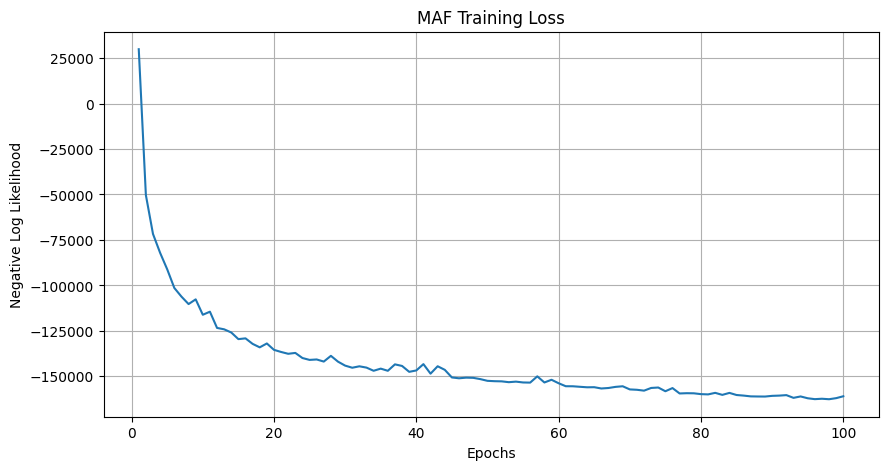


--- Starting Sampling Phase ---
Starting generation of 5 images. This is strictly sequential.
  > Inverting Block 7/7...


  > Inverting Block 6/7...


  > Inverting Block 5/7...


  > Inverting Block 4/7...


  > Inverting Block 3/7...


  > Inverting Block 2/7...


  > Inverting Block 1/7...


Sampling finished in 1995.75 seconds.


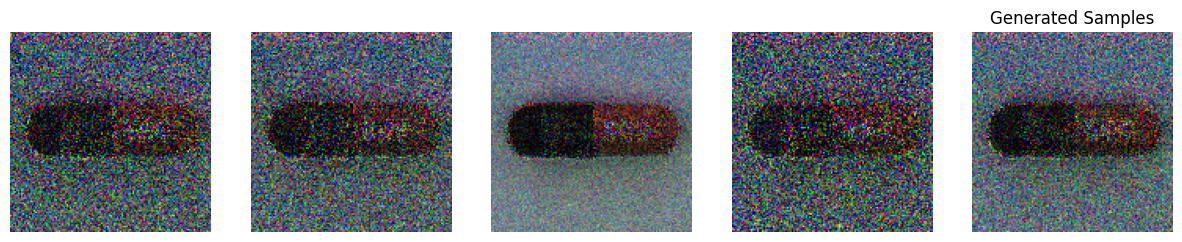

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import time
from tqdm import tqdm

DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE=8
EPOCHS=100
LR=1e-4
IMAGE_SIZE=128
INPUT_DIM=IMAGE_SIZE*IMAGE_SIZE*3
HIDDEN_DIM=512 
BLOCKS=7
DATA_PATH="/kaggle/input/mvtec-ad/capsule/train/good/*.png"

class MVTecDataset(Dataset):
    def __init__(self,image_paths,transform=None):
        self.image_paths=image_paths
        self.transform=transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self,idx):
        img_path =self.image_paths[idx]
        image=Image.open(img_path).convert("RGB")
        if self.transform:
            image=self.transform(image)
        
        noise=torch.rand_like(image)/256.0
        image=image+noise
        return image

image_files=glob.glob(DATA_PATH)
if not image_files:
    print("Warning: Direct path empty, searching recursively...")
    image_files=glob.glob("/kaggle/input/mvtec-ad/capsule/**/*.png",recursive=True)
    image_files=[f for f in image_files if 'train' in f and 'good' in f]

print(f"Found {len(image_files)} training images.")

transform=transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.ToTensor(),
])

dataset=MVTecDataset(image_files,transform=transform)
dataloader=DataLoader(dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=2)

class MaskedLinear(nn.Linear):
    def __init__(self,in_features,out_features,bias=True):
        super(MaskedLinear,self).__init__(in_features,out_features,bias)
        self.register_buffer('mask',torch.ones(out_features,in_features))

    def set_mask(self,mask):
        self.mask.data.copy_(mask)

    def forward(self,input):
        return F.linear(input,self.mask*self.weight,self.bias)

class MADE(nn.Module):
    def __init__(self,input_dim,hidden_dim):
        super(MADE,self).__init__()
        self.input_dim=input_dim
        self.hidden_dim=hidden_dim
        
        self.net=nn.Sequential(
            MaskedLinear(input_dim,hidden_dim),
            nn.ReLU(),
            MaskedLinear(hidden_dim,hidden_dim),
            nn.ReLU(),
            MaskedLinear(hidden_dim,input_dim*2)
        )
        self.create_masks()

    def create_masks(self):
        L=3
        self.m={}
        self.m[-1]=torch.arange(self.input_dim)
        for l in range(L-1):
            self.m[l]=torch.randint(self.m[-1].min(),self.input_dim-1,size=(self.hidden_dim,))
        
        masks=[]
        masks.append(self.m[0].unsqueeze(-1)>=self.m[-1].unsqueeze(0))
        masks.append(self.m[1].unsqueeze(-1)>=self.m[0].unsqueeze(0))
        m_out=self.m[-1].repeat(2)
        masks.append(m_out.unsqueeze(-1)>self.m[1].unsqueeze(0))
        
        layers=[self.net[0],self.net[2],self.net[4]]
        for layer,mask in zip(layers,masks):
            layer.set_mask(mask.float())

    def forward(self,x):
        out=self.net(x)
        mu,log_alpha=out.chunk(2,dim=1)
        return mu,log_alpha

class MAF(nn.Module):
    def __init__(self,num_blocks,input_size,hidden_size):
        super(MAF,self).__init__()
        self.input_size=input_size
        self.made_blocks=nn.ModuleList([
            MADE(input_size,hidden_size) for _ in range(num_blocks)
        ])
        self.register_buffer('base_dist_mean',torch.zeros(1))
        self.register_buffer('base_dist_var',torch.ones(1))

    def forward(self,x):
        bs=x.shape[0]
        x=x.view(bs,-1) 
        u=x
        log_det_jac=0
        
        for made in self.made_blocks:
            mu,log_alpha=made(u)
            u=(u-mu)*torch.exp(-log_alpha)
            log_det_jac+=-log_alpha.sum(dim=1)
        
        base_log_prob=-0.5*(torch.log(2*torch.pi*self.base_dist_var)+u**2).sum(dim=1)
        log_prob=base_log_prob+log_det_jac
        return -log_prob.mean()

    def sample(self,num_samples,device):

        print(f"Starting generation of {num_samples} images. This is strictly sequential.")
        self.eval()
        with torch.no_grad():
            x=torch.randn(num_samples,self.input_size).to(device)
            
            for block_idx,made in enumerate(reversed(self.made_blocks)):
                print(f"  > Inverting Block {BLOCKS-block_idx}/{BLOCKS}...")
                
                z_in=x.clone()
                x_out=torch.zeros_like(z_in)

                iterator=tqdm(range(self.input_size),desc="Pixel-wise Generation",leave=False)
                
                for i in iterator:

                    mu,log_alpha=made(x_out)
                    

                    x_out[:,i]=z_in[:,i]*torch.exp(log_alpha[:,i])+mu[:,i]
                
                x=x_out
                
        return x.view(num_samples,3,128,128)

model=MAF(BLOCKS,INPUT_DIM,HIDDEN_DIM).to(DEVICE)
optimizer=torch.optim.Adam(model.parameters(),lr=LR)

print(f"Starts Training for {EPOCHS} epochs...")
train_start_time=time.time()
loss_history=[]

for epoch in range(EPOCHS):
    epoch_loss=0
    batch_iterator=tqdm(dataloader,desc=f"Epoch {epoch+1}/{EPOCHS}",leave=False)
    
    for batch in batch_iterator:
        batch=batch.to(DEVICE)
        
        optimizer.zero_grad()
        loss=model(batch)
        loss.backward()
        optimizer.step()
        
        epoch_loss+=loss.item()
        batch_iterator.set_postfix(loss=loss.item())

    avg_loss=epoch_loss/len(dataloader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}: Average Loss = {avg_loss:.4f}")

train_end_time=time.time()
print(f"Training finished in {train_end_time-train_start_time:.2f} seconds.")

plt.figure(figsize=(10,5))
plt.plot(range(1,EPOCHS+1),loss_history,label='NLL Loss')
plt.xlabel('Epochs')
plt.ylabel('Negative Log Likelihood')
plt.title('MAF Training Loss')
plt.grid()
plt.savefig('training_loss.png')
plt.show()

print("\n--- Starting Sampling Phase ---")
print("WARNING: This step calculates 49,152 pixels sequentially * 7 blocks.")
sampling_start_time=time.time()

try:

    generated_images=model.sample(num_samples=5,device=DEVICE)
    
    sampling_end_time=time.time()
    print(f"Sampling finished in {sampling_end_time-sampling_start_time:.2f} seconds.")

    generated_images=generated_images.cpu().clamp(0,1)
    fig,axs=plt.subplots(1,5,figsize=(15,5))
    for i in range(5):
        axs[i].imshow(generated_images[i].permute(1,2,0).numpy())
        axs[i].axis('off')
    plt.title("Generated Samples")
    plt.show()

except KeyboardInterrupt:
    print("\nSampling interrupted manually (It was taking too long, as expected).")

Test samples found: 132
Normal count: 23
Anomaly count: 109
Starting Evaluation on Test Set...


Evaluating: 100%|██████████| 132/132 [00:11<00:00, 11.90it/s]




Evaluation Result for Linear MAF:
AUROC Score:            72.56%
AUPR Score (Avg Prec):  92.65%
Optimal F1-Score:       91.60%
  (Best Threshold:      -160942.8906)


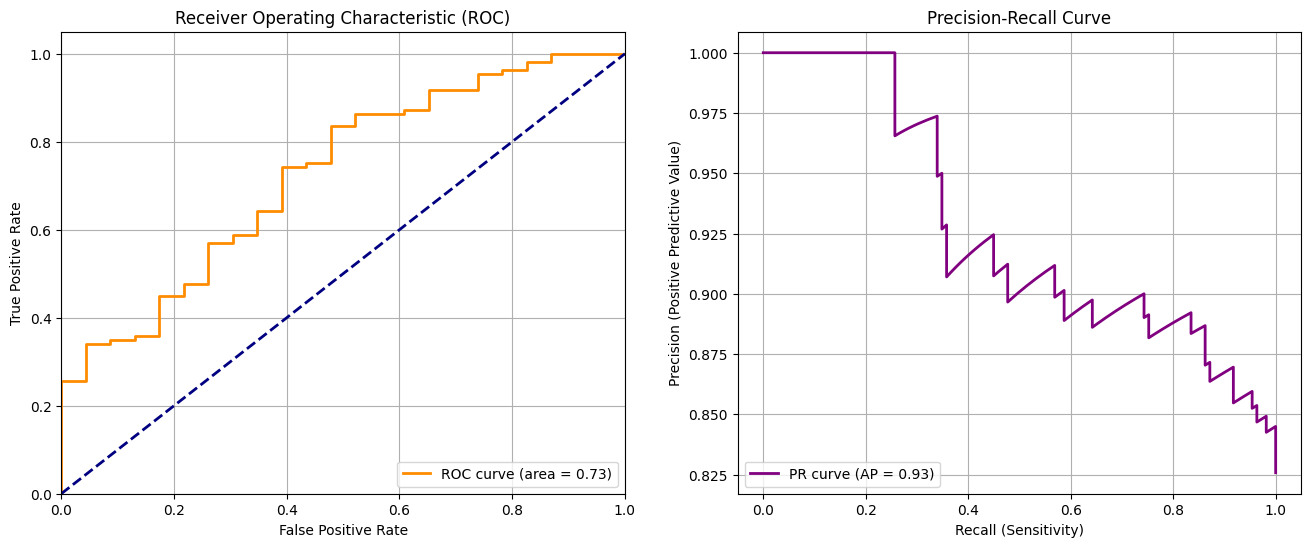

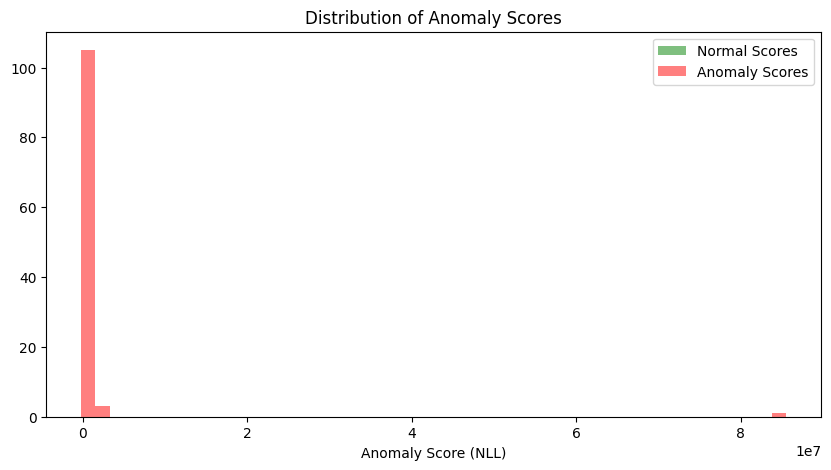

In [7]:
import torch
from torch.utils.data import Dataset,DataLoader
import torchvision.transforms as transforms
from sklearn.metrics import roc_auc_score,average_precision_score,precision_recall_curve,roc_curve
import numpy as np
from tqdm import tqdm
import glob
import os
from PIL import Image
import matplotlib.pyplot as plt

DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MVTecTestDataset(Dataset):
    def __init__(self,root_dir,transform=None):
        self.image_paths=[]
        self.labels=[]
        self.transform=transform
        

        all_files=glob.glob(os.path.join(root_dir,"test","**","*.png"),recursive=True)
        
        for path in all_files:
            self.image_paths.append(path)
            if 'good' in path.split(os.sep):
                self.labels.append(0)
            else:
                self.labels.append(1)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path=self.image_paths[idx]
        image=Image.open(img_path).convert("RGB")
        label=self.labels[idx]
        
        if self.transform:
            image=self.transform(image)
        
        noise=torch.rand_like(image)/256.0
        image=image+noise
        
        return image,label

test_root="/kaggle/input/mvtec-ad/capsule" 


test_dataset=MVTecTestDataset(root_dir=test_root,transform=transform)
test_loader=DataLoader(test_dataset,batch_size=1,shuffle=False)

print(f"Test samples found: {len(test_dataset)}")
print(f"Normal count: {test_dataset.labels.count(0)}")
print(f"Anomaly count: {test_dataset.labels.count(1)}")

def calculate_anomaly_score(model,x):
    model.eval()
    with torch.no_grad():
        bs=x.shape[0]
        x_flat=x.view(bs,-1)
        u=x_flat
        log_det_jac=0
        
        for made in model.made_blocks:
            mu,log_alpha=made(u)
            u=(u-mu)*torch.exp(-log_alpha)
            log_det_jac+= -log_alpha.sum(dim=1)
        
        base_log_prob=-0.5*(torch.log(2*torch.pi*model.base_dist_var)+u**2).sum(dim=1)
        log_prob=base_log_prob+log_det_jac
        
        return -log_prob

y_true=[]
y_scores=[]

print("Starting Evaluation on Test Set...")
for img,label in tqdm(test_loader,desc="Evaluating"):
    img=img.to(DEVICE)
    
    score=calculate_anomaly_score(model,img)
    
    y_true.append(label.item())
    y_scores.append(score.item())

auroc_score=roc_auc_score(y_true,y_scores)
aupr_score=average_precision_score(y_true,y_scores)

precision,recall,pr_thresholds=precision_recall_curve(y_true,y_scores)

numerator=2*(precision*recall)
denominator=(precision+recall)+1e-10 
f1_scores=numerator/denominator

optimal_f1=np.max(f1_scores)
optimal_idx=np.argmax(f1_scores)

if optimal_idx<len(pr_thresholds):
    best_threshold=pr_thresholds[optimal_idx]
else:
    best_threshold=0

print(f"\n\n========================================")
print(f"Evaluation Result for Linear MAF:")
print(f"AUROC Score:            {auroc_score * 100:.2f}%")
print(f"AUPR Score (Avg Prec):  {aupr_score * 100:.2f}%")
print(f"Optimal F1-Score:       {optimal_f1 * 100:.2f}%")
print(f"  (Best Threshold:      {best_threshold:.4f})")
print(f"========================================")

fpr,tpr,roc_thresholds=roc_curve(y_true, y_scores) 

plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
plt.plot(fpr,tpr,color='darkorange',lw=2,label=f'ROC curve (area = {auroc_score:.2f})')
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)


plt.subplot(1,2,2)
plt.plot(recall,precision,color='purple',lw=2,label=f'PR curve (AP = {aupr_score:.2f})')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)

plt.show()

plt.figure(figsize=(10,5))
scores_normal=[s for s,l in zip(y_scores,y_true) if l==0]
scores_anomaly=[s for s,l in zip(y_scores,y_true) if l==1]

plt.hist(scores_normal,bins=50,alpha=0.5,label='Normal Scores',color='green')
plt.hist(scores_anomaly,bins=50,alpha=0.5,label='Anomaly Scores',color='red')
plt.xlabel('Anomaly Score (NLL)')
plt.title('Distribution of Anomaly Scores')
plt.legend()
plt.show()